#### Step 1: Fetch Movie Data from API

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import os

In [2]:
# Load config 
try:
    with open("../config.json") as config_file:
        config = json.load(config_file)
    api_token = config["TMDB_API_KEY"]
except Exception as e:
    print(f"Error loading config: {e}")
    exit(1)

# Set up headers
headers = {
    "Authorization": f"Bearer {api_token}"
}

# List of movie IDs
movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397,
            420818, 24428, 168259, 99861, 284054, 12445,
            181808, 330457, 351286, 109445, 321612, 260513]

movies_data = []

# Fetch movie data 
for movie_id in movie_ids:
    try:
        url = f"https://api.themoviedb.org/3/movie/{movie_id}?append_to_response=reviews,credits"
        response = requests.get(url, headers=headers, timeout=10)                                #Adds a timeout to API requests to prevent hanging
        
        if response.status_code == 200:
            movies_data.append(response.json())
            print(f"Successfully fetched movie ID: {movie_id}")
        else:
            print(f"Failed to fetch movie ID: {movie_id}, Status code: {response.status_code}")
    except Exception as e:
        print(f"Error fetching movie ID {movie_id}: {e}")

"""
Makes sure the output directory exists before saving and 
checks if any data was retrieved before creating the DataFrame
 """
try:
    # Create DataFrame
    if movies_data:
        raw_movies_df = pd.DataFrame(movies_data)
        
        # Make sure directory exists
        os.makedirs(os.path.dirname("../data/raw/"), exist_ok=True)
        
        # Save to CSV
        raw_movies_df.to_csv("../data/raw/raw_tmdb_movies.csv", index=False)
        print("Movie data with reviews and credits saved to raw_tmdb_movies.csv")
    else:
        print("No movie data retrieved. Cannot create CSV.")
except Exception as e:
    print(f"Error saving data: {e}")

Failed to fetch movie ID: 0, Status code: 404
Successfully fetched movie ID: 299534
Successfully fetched movie ID: 19995
Successfully fetched movie ID: 140607
Successfully fetched movie ID: 299536
Successfully fetched movie ID: 597
Successfully fetched movie ID: 135397
Successfully fetched movie ID: 420818
Successfully fetched movie ID: 24428
Successfully fetched movie ID: 168259
Successfully fetched movie ID: 99861
Successfully fetched movie ID: 284054
Successfully fetched movie ID: 12445
Successfully fetched movie ID: 181808
Successfully fetched movie ID: 330457
Successfully fetched movie ID: 351286
Successfully fetched movie ID: 109445
Successfully fetched movie ID: 321612
Successfully fetched movie ID: 260513
Movie data with reviews and credits saved to raw_tmdb_movies.csv


#### Step 2: Data Cleaning and Preprocessing

In [3]:
import cleaning as cl

extracted_df = cl.get_movie_columns(raw_movies_df )

extracted_df=cl.clean_movie_data(
    
                                 df=extracted_df, 
                                 pipe_columns=['genres', 'spoken_languages', 'production_countries', 'production_companies'], 
                                 collection_col='belongs_to_collection', 
                                 columns_to_drop=['adult', 'imdb_id', 'original_title', 'video', 'homepage','reviews','credits','backdrop_path']
)

Data cleaning completed.


##### Handling Missing & Incorrect Data

In [4]:

# Defined list of columns for processing
numeric_columns = ['budget','revenue','id', 'popularity', 'vote_average', 'vote_count', 'rating', 'crew_size', 'cast_size', 'runtime']
money_columns = ['budget', 'revenue'] 
# a list of placeholders to replace with NaN
placeholders = ['no data', 'none', 'n/a', '']



# Iterates over the numeric_columns and convert each to numeric while replacing 0s with NaN
for col in numeric_columns:
    extracted_df[col] = pd.to_numeric(extracted_df[col], errors='coerce').replace(0, np.nan)


# Converts date column to datetime format and ignores errors if table isn't available
extracted_df['release_date'] = pd.to_datetime(extracted_df['release_date'], errors='coerce')


# Iterates over the money_columns lists and converts them to millions 
for col in money_columns:
    if col in extracted_df.columns:
        extracted_df[col] = extracted_df[col]/ 1_000_000

#this helps to rename budget and revenue columns...musd(millions in USD)
extracted_df = extracted_df.rename(columns={'budget': 'budget_musd', 'revenue': 'revenue_musd'})



#This creates a list of columns for all columns of type object to strings
str_cols = extracted_df.select_dtypes(include='object').columns

for col in str_cols:
    cleaned_col = extracted_df[col].astype(str).str.strip().str.lower() # Convert to string, strip whitespace, and lowercase
    extracted_df[col] = cleaned_col.mask(cleaned_col.isin(placeholders), np.nan) # Replaces placeholders with NaN for column being iterated   Used mask to replace only the specified placeholders since replace is deprecated


+ Remove duplicates and drop rows with unknown 'id' or 'title'.
+ Keep only rows where at least 10 columns have non-NaN values.
+ this returns a dataframe called processed_df as befitting of the current step of the pipeline

In [5]:
processed_df = (
    extracted_df
    .dropna(thresh=10) #drops rows with more than 10 NaN
    .drop_duplicates() # drop duplicate rows 
    .dropna(subset=['id', 'title']) #this makes sure a row with unknown 'id' or 'title' is dropped
)

In [6]:
reordered_columns = [
    'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
    'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
    'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
    'overview', 'spoken_languages', 'poster_path','cast', 'cast_size', 'directors', 'crew_size','rating'
]
processed_df = processed_df[reordered_columns].reset_index(drop=True)
# Save the processed DataFrame to a CSV file
processed_df.to_csv("../data/processed/processed_tmdb_movies.csv", index=False) # saves the reordered dataframe 'processed_df' to a csv file with no indexing


#### Step 3: KPI Implementation & Analysis

##### Identify the Best/Worst Performing Movies

In [7]:
import kpi_implementation as kpi #imports module containing functions  for kpi analysis

#added a profits(Revenue - Budget) column to the processed_df to aid in KPI analysis
processed_df['profit'] = processed_df['revenue_musd'] - processed_df['budget_musd']


#added a roi(Revenue / Budget) column to the processed_df to aid in KPI analysis
processed_df['roi'] = np.where(     
   processed_df['budget_musd'] > 0,
   processed_df['revenue_musd'] / processed_df['budget_musd'],
    np.nan  
) # np.where() helps  avoid division by zero which may lead to erros


# Generate all rankings
all_rankings = kpi.get_movie_rankings(processed_df) #UDF that returns a dictionary of ranked dataframes derived from the processed_df 


In [8]:
#filtered and ranked dataframes based on kpi
highest_revenue = all_rankings["Highest Revenue"]
highest_budget = all_rankings["Highest Budget"]
highest_profit =all_rankings["Highest Profit"]
lowest_profit = all_rankings["Lowest Profit"]
highest_roi = all_rankings["Highest ROI (Budget ≥ 10M)"]
lowest_roi = all_rankings["Lowest ROI (Budget ≥ 10M)"]
most_voted = all_rankings["Most Voted Movies"]
highest_rated = all_rankings['Highest Rated Movies (≥10 votes)']
lowest_rated = all_rankings["Lowest Rated Movies (≥10 votes)"]
most_popular = all_rankings["Most Popular Movies"]
shortest_runtime =all_rankings["Shortest Runtime Movies"]

##### Filter the dataset for specific queries

In [9]:
best_rated_scifi_action_movie = highest_rated.query( "'Science Fiction' in genres and 'Action' in genres and 'Bruce Willis' in cast" )
#used the highest_rated dataframe since it's already sorted by rating in descending order

In [10]:
shortest_runtime_movie=shortest_runtime.query("'Uma Thurman' in cast and 'Quentin Tarantino' in directors")
#used the shortest_runtime dataframe since its already sorted by runtime in ascending order

#### 

##### Compare movie franchises (belongs_to_collection) vs. standalone movies

In [11]:
# a dictionary of metrics to calculate
metrics = {
    'revenue_musd': 'mean', 
    'roi': 'median',
    'budget_musd': 'mean',
    'popularity': 'mean',
    'vote_average': 'mean'
}

# returns a dataframe 'comparison_df' grouped by whether movies belong to collections with the specified metrics
comparison_df = (processed_df
    .assign(is_franchise=processed_df['belongs_to_collection'].notna())
    .groupby('is_franchise')
    .agg(metrics)
    .T #transposes the datframe to have the metrics as rows for better presentation
    .rename(columns={False: 'Standalone Movies', True: 'Franchise Movies'})
)

# Rename the index for better readability
comparison_df.index = ['Mean Revenue', 'Median ROI', 'Mean Budget', 'Mean Popularity', 'Mean Rating']

# Adds the comparison of franchise vs standalone to my all_rankings dictionary of dataframes
all_rankings["Franchise vs Standalone"] = comparison_df

#### Finding the Most Successful Movie Franchises Based on specified metrics

In [12]:
franchise_df = processed_df.query("belongs_to_collection.notna()") # creates a df of only franchise movies

##### most successful franchises based on 

In [13]:
# Step 2 & 3: Group and aggregate key franchise metrics
franchise_metrics = (
    franchise_df
    .groupby("belongs_to_collection")
    .agg(
        total_movies=('id', 'count'),
        total_budget=('budget_musd', 'sum'),
        mean_budget=('budget_musd', 'mean'),
        total_revenue=('revenue_musd', 'sum'),
        mean_revenue=('revenue_musd', 'mean'),
        mean_rating=('vote_average', 'mean')
    )
)


+ total number of movies in franchise
+ total number of movies in franchise and mean budget
+ total number of movies in franchise and mean revenue
+ mean rating

In [14]:
franchise_metrics[['total_movies']].sort_values(['total_movies'], ascending=False).head() #total number of movies in franchise
franchise_metrics[['total_movies','mean_budget']].sort_values(['total_movies','mean_budget'], ascending=False).head() #total number of movies in franchise and mean budget
franchise_metrics[['total_movies','mean_revenue']].sort_values(['total_movies','mean_revenue'], ascending=False).head() #total number of movies in franchise and mean revenue
franchise_metrics[['mean_rating']].sort_values("mean_rating", ascending=False).head()   #mean rating

,mean_rating
belongs_to_collection,
harry potter collection,8.0870
the avengers collection,7.8705
avatar collection,7.5880
the incredibles collection,7.4540
black panther collection,7.3730


##### most successful directors based on 

In [15]:
#Group and aggregate key director metrics
director_metrics=(
    processed_df.groupby('directors').agg(
        total_movies=('id', 'count'),
        total_revenue=('revenue_musd', 'sum'),
        mean_rating=('vote_average', 'mean'))
)

+ total number of movies directed
+ total revenue
+ mean rating

In [16]:
director_metrics[['total_movies']].sort_values(['total_movies'], ascending=False).head()
director_metrics[['total_revenue']].sort_values(['total_revenue'], ascending=False).head()
director_metrics[['mean_rating']].sort_values("mean_rating", ascending=False).head()

,mean_rating
directors,
"['anthony russo', 'joe russo']",8.237
"['joe russo', 'anthony russo']",8.235
['david yates'],8.087
['james cameron'],7.747
['joss whedon'],7.505


### Data Visualization

+ Use Pandas, Matplotlib to visualize:

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

+ Revenue vs. Budget Trends
+ scatter plot was used to show the trends 

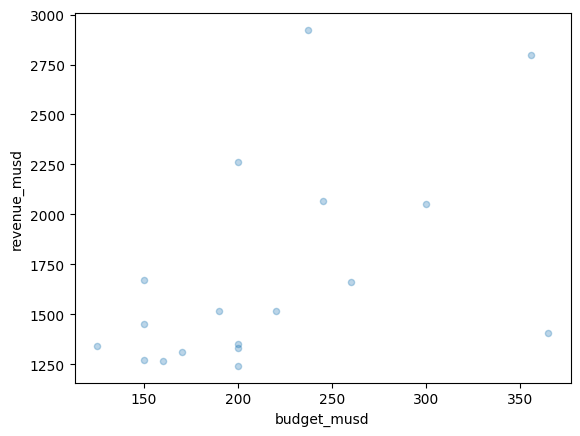

In [18]:
processed_df.plot.scatter(x='budget_musd', y='revenue_musd', alpha=0.3); plt.show()

#### ROI Distribution by Genre
+ grouped processed_df by genres(genres had multiple values so it was each row separated to help group by distinct genre categories)

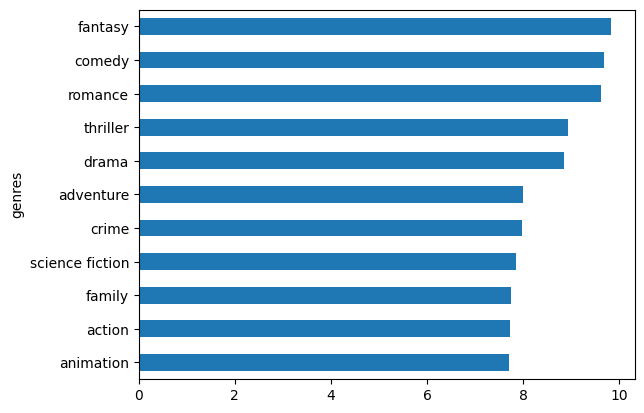

In [19]:
processed_df.assign(genres=processed_df['genres'].str.split('|')).explode('genres').groupby('genres')['roi'].mean().sort_values().plot.barh(); plt.show()

#### Popularity vs Rating
+ scatter plot was used

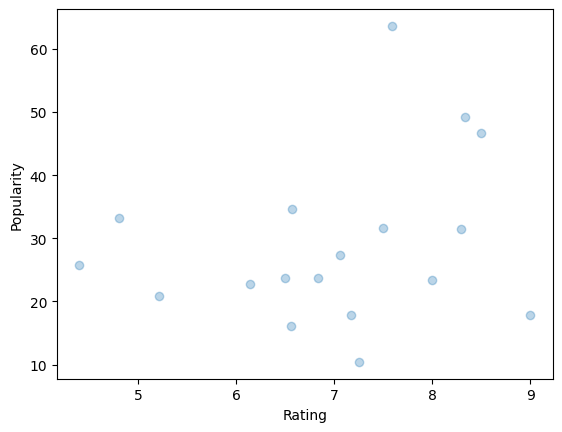

In [20]:
plt.scatter(processed_df['rating'], processed_df['popularity'], alpha=0.3)
plt.xlabel('Rating'); plt.ylabel('Popularity'); plt.show()

### Yearly Trends in Box Office Performance
+ release_date values were converted to only the year format to help group the dataframe
+ average revenue was used as a performance metric over the years

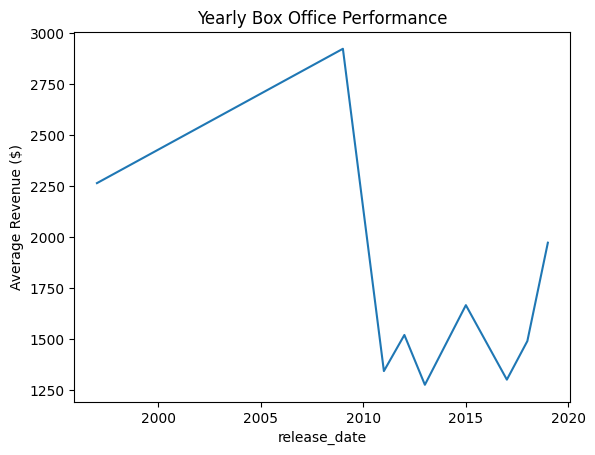

In [21]:
#group by release date

# Plot yearly trends
processed_df.groupby(processed_df['release_date'].dt.year)['revenue_musd'].mean().plot()
plt.ylabel('Average Revenue ($)')
plt.title('Yearly Box Office Performance')
plt.show()

#### Comparison of Franchise vs. Standalone Success

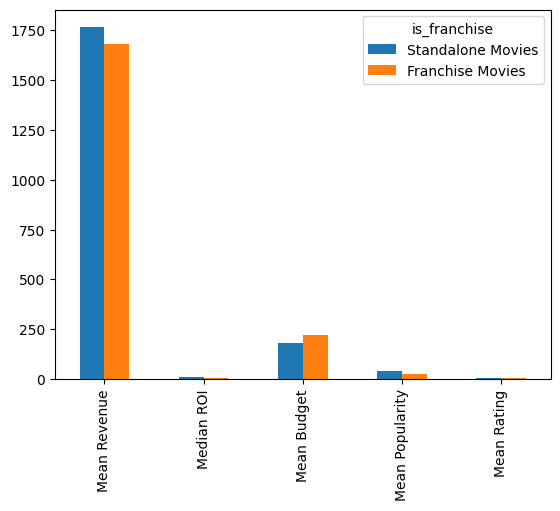

In [22]:
comparison_df.plot.bar(); plt.show()